Using: mps
✅ 28709 images, 7 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
✅ CNN ready (6M params)
Epoch 1: Loss=1.646, Acc=34.4%
Epoch 2: Loss=1.403, Acc=46.0%
Epoch 3: Loss=1.282, Acc=51.3%
Epoch 4: Loss=1.193, Acc=54.9%
Epoch 5: Loss=1.118, Acc=57.5%


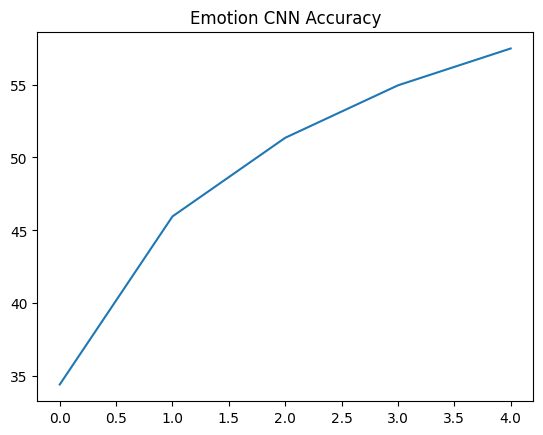

✅ SAVED emotion_cnn.pth → READY FOR FUSION!
Frustration classes: angry(0)=sad(4)


In [4]:
# === CELL 1: Imports + setup ===
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using: {device}")  # Mac GPU!

# Data transforms
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ✅ FORCE 1 channel
    transforms.Resize((48,48)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


# === CELL 2: Load FER2013 ===
base = Path("..") / "data" / "raw" / "fer2013"
dataset = datasets.ImageFolder(base / "train", transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

classes = dataset.classes  # ['angry','disgust',...]
print(f"✅ {len(dataset)} images, {len(classes)} classes: {classes}")

# === CELL 3: Simple CNN ===
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128*6*6, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = EmotionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ CNN ready (6M params)")

# === CELL 4: Train (5 mins) ===
model.train()
losses, accuracies = [], []

for epoch in range(5):  # Quick train
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in dataloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    losses.append(epoch_loss)
    accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}: Loss={epoch_loss:.3f}, Acc={epoch_acc:.1f}%")

plt.plot(accuracies)
plt.title("Emotion CNN Accuracy")
plt.savefig("../results/figures/emotion_acc.png")
plt.show()

# === CELL 5: Save model ===
torch.save(model.state_dict(), "../models/emotion_cnn.pth")
print("✅ SAVED emotion_cnn.pth → READY FOR FUSION!")
print("Frustration classes: angry(0)=sad(4)")
